# NRT threshold selection

Chooses the probability threshold of the near real time rule, from the per-acquisition
scores written by `nrt_scores.py`. It answers two questions: does the score separate the
acquisitions before an event from those after it, and does the joint mode separate them
better than the optical one.

It does **not** measure timeliness. Applying the rule to each polygon and comparing its
alert date with VIEW_DATE is a separate step, run on the test split once the threshold
here is fixed.

Copy `nrt_scores/` from the cluster next to this notebook first. `nrt_roc.py` produces the
same curves as a script; this notebook is for looking at the numbers before fixing them.

In [1]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             roc_auc_score, average_precision_score)

SCORES = 'nrt_scores'          # folder copied from the cluster
MODEL, VER = 'log_reg', '3'    # switch MODEL to 'rf' to repeat everything
MODES = ['optical', 'joint']
COL = {'optical': '#eb6834', 'joint': '#2a78d6'}


def load(mode, model=MODEL, ver=VER):
    files = glob.glob(f'{SCORES}/{mode}_{model}_v{ver}/fid_*.csv')
    if not files:
        raise FileNotFoundError(f'{SCORES}/{mode}_{model}_v{ver}/ is empty')
    return pd.concat(map(pd.read_csv, files), ignore_index=True)


d = {m: load(m) for m in MODES}
d['optical'].head()

,date,win,n_tok,p_sum,n_nonforest,n_tiles,pc_sum,p_dist,p_class,fid,mode,model,view_date,days
0,2023-04-30,bef,28,8.584589,4,4,1.769166,0.306592,0.063184,327,optical,log_reg,2023-08-15,-107
1,2023-05-15,bef,28,13.539002,11,4,3.982097,0.483536,0.142218,327,optical,log_reg,2023-08-15,-92
2,2023-06-04,bef,28,11.009270,11,4,1.810979,0.393188,0.064678,327,optical,log_reg,2023-08-15,-72
3,2023-06-09,bef,28,8.243740,4,4,2.128912,0.294419,0.076033,327,optical,log_reg,2023-08-15,-67
4,2023-06-19,bef,28,4.580670,4,4,1.018101,0.163595,0.036361,327,optical,log_reg,2023-08-15,-57


## 1. Are the two samples comparable?

The joint series needs a Sentinel-1 acquisition paired to each Sentinel-2 one, so it holds
fewer dates. If the two modes cover different polygons or different dates, a difference
between their curves cannot be attributed to the representation.

In [2]:
for m, x in d.items():
    print(f'{m:8s}: {x.fid.nunique():3d} polygons | {len(x):5d} acquisitions | '
          f'{(x.win == "aft").sum():4d} after ({(x.win == "aft").mean():.1%} positives)')

o, j = d['optical'], d['joint']
print('\nonly in optical:', sorted(set(o.fid) - set(j.fid)))
print('only in joint  :', sorted(set(j.fid) - set(o.fid)))

ko, kj = set(zip(o.fid, o.date)), set(zip(j.fid, j.date))
print(f'\nshared (fid, date): {len(ko & kj)}')
print(f'  optical only    : {len(ko - kj)}')
print(f'  joint only      : {len(kj - ko)}   <- should be 0')

optical : 174 polygons |  2263 acquisitions |  341 after (15.1% positives)
joint   : 173 polygons |  1439 acquisitions |  192 after (13.3% positives)

only in optical: [224]
only in joint  : []

shared (fid, date): 1439
  optical only    : 824
  joint only      : 0   <- should be 0


## 2. ROC and precision recall

`bef` is the negative class and `aft` the positive one. The event window straddles the
reference date, so it is dropped. `buffer` additionally drops the before acquisitions that
fall within that many days of the reference date.

optical  AUC 0.891 | AP 0.615 | baseline 0.170 | rows 2003
joint    AUC 0.886 | AP 0.541 | baseline 0.147 | rows 1305


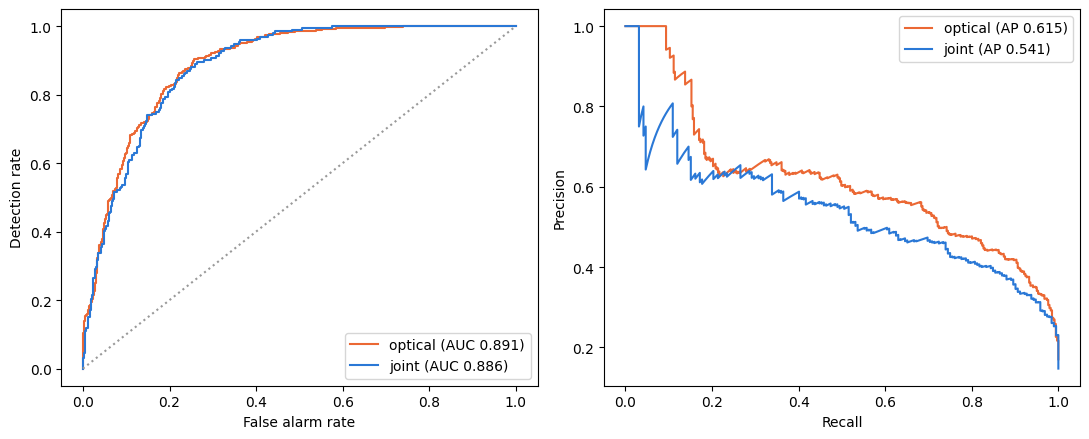

In [3]:
def curves(x, buffer=0, match=None):
    x = x[x.win != 'evt']
    if match is not None:
        x = x[[k in match for k in zip(x.fid, x.date)]]
    if buffer:
        x = x[(x.win == 'aft') | (x.days <= -buffer)]
    y = (x.win == 'aft').astype(int)
    fpr, tpr, thr = roc_curve(y, x.p_dist)
    prec, rec, _ = precision_recall_curve(y, x.p_dist)
    return dict(fpr=fpr, tpr=tpr, thr=thr, prec=prec, rec=rec,
                auc=roc_auc_score(y, x.p_dist),
                ap=average_precision_score(y, x.p_dist),
                pos=y.mean(), n=len(x))


fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.5))
for m in MODES:
    c = curves(d[m])
    a1.plot(c['fpr'], c['tpr'], color=COL[m], label=f'{m} (AUC {c["auc"]:.3f})')
    a2.plot(c['rec'], c['prec'], color=COL[m], label=f'{m} (AP {c["ap"]:.3f})')
    print(f'{m:8s} AUC {c["auc"]:.3f} | AP {c["ap"]:.3f} | '
          f'baseline {c["pos"]:.3f} | rows {c["n"]}')

a1.plot([0, 1], [0, 1], ':', color='0.6')
a1.set_xlabel('False alarm rate'); a1.set_ylabel('Detection rate'); a1.legend()
a2.set_xlabel('Recall'); a2.set_ylabel('Precision'); a2.legend()
plt.tight_layout()

## 3. The modes at an equal false alarm rate

The two modes produce probabilities from different classifiers, so the same threshold does
not mean the same thing in both. This is the comparison that answers whether radar adds
anything.

In [4]:
for target in [0.02, 0.05, 0.10]:
    print(f'--- false alarm rate {target:.0%}')
    for m in MODES:
        c = curves(d[m])
        i = min(int(np.searchsorted(c['fpr'], target)), len(c['thr']) - 1)
        print(f'  {m:8s} tau {c["thr"][i]:.3f} -> detection {c["tpr"][i]:.3f}')
    print()

--- false alarm rate 2%
  optical  tau 0.987 -> detection 0.196
  joint    tau 0.988 -> detection 0.203

--- false alarm rate 5%
  optical  tau 0.970 -> detection 0.428
  joint    tau 0.972 -> detection 0.401

--- false alarm rate 10%
  optical  tau 0.943 -> detection 0.630
  joint    tau 0.948 -> detection 0.562



## 4. Matched dates

Same as above but restricted to the acquisitions present in both modes, so the comparison
isolates the representation instead of the number of dates each mode has.

In [5]:
shared = ko & kj
for m in MODES:
    c = curves(d[m], match=shared)
    i = int(np.argmax(c['tpr'] - c['fpr']))
    print(f'{m:8s} rows {c["n"]:5d} | AUC {c["auc"]:.3f} | AP {c["ap"]:.3f} | '
          f'tau {c["thr"][i]:.3f} -> detection {c["tpr"][i]:.3f}, '
          f'false alarm {c["fpr"][i]:.3f}')

optical  rows  1305 | AUC 0.888 | AP 0.558 | tau 0.860 -> detection 0.880, false alarm 0.229
joint    rows  1305 | AUC 0.886 | AP 0.541 | tau 0.851 -> detection 0.896, false alarm 0.264


## 5. How much signal is there before the reference date?

The reference date is when DETER detected the event, not when it happened. Dropping the
before acquisitions closest to it should lower the false alarm rate if part of what is
counted as a false alarm is in fact an early detection. Where the rate stops falling is an
estimate of how much earlier the signal appears.

In [6]:
rows = []
for m in MODES:
    for b in [0, 15, 30, 45, 60, 90]:
        c = curves(d[m], buffer=b)
        i = int(np.argmax(c['tpr'] - c['fpr']))
        rows.append(dict(mode=m, buffer=b, rows=c['n'], positives=round(c['pos'], 3),
                         auc=round(c['auc'], 3), tau=round(c['thr'][i], 3),
                         detection=round(c['tpr'][i], 3),
                         false_alarm=round(c['fpr'][i], 3)))

sweep = pd.DataFrame(rows)
sweep

,mode,buffer,rows,positives,auc,tau,detection,false_alarm
0,optical,0,2003,0.170,0.891,0.842,0.903,0.258
1,optical,15,1913,0.178,0.900,0.842,0.903,0.242
2,optical,30,1648,0.207,0.912,0.842,0.903,0.216
3,optical,45,1429,0.239,0.915,0.842,0.903,0.208
4,optical,60,1209,0.282,0.917,0.842,0.903,0.207
5,optical,90,815,0.418,0.923,0.842,0.903,0.196
6,joint,0,1305,0.147,0.886,0.851,0.896,0.264
7,joint,15,1261,0.152,0.894,0.851,0.896,0.252
8,joint,30,1102,0.174,0.907,0.862,0.880,0.210
9,joint,45,959,0.200,0.910,0.862,0.880,0.203


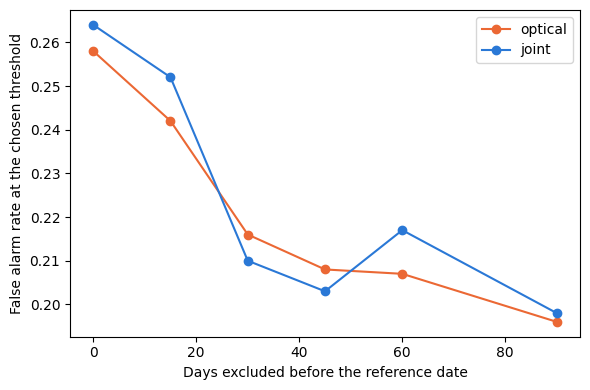

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
for m in MODES:
    s = sweep[sweep['mode'] == m]
    ax.plot(s.buffer, s.false_alarm, 'o-', color=COL[m], label=m)
ax.set_xlabel('Days excluded before the reference date')
ax.set_ylabel('False alarm rate at the chosen threshold')
ax.legend()
plt.tight_layout()